Description...

In [2]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

from datetime import datetime
import glob
from invisible_cities.reco.corrections import read_maps
from invisible_cities.reco.corrections import apply_all_correction
from invisible_cities.types.symbols    import NormStrategy
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import scipy

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Configuration

In [2]:
# ----- Processing Details ----- #
# Complete these options before running the notebook.
# It will be used to define the input and output paths, as well as the analysis type and date for the plots.
PROCESS_TYPE = 'hpr'                            # Options: 'lpr', 'hpr'
DATE = datetime.now().strftime('%d%m%Y')        # Options: today or some day (e.g '02122025')

In [70]:
# --------------------------------------------
# 1. MC DIRECTORIES, PATHS, KEYS AND FILENAMES
# --------------------------------------------
MC_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/'
ISOTOPES = ['Bi214', 'Co60', 'K40', 'Tl208']
MC_PATHS = []

if PROCESS_TYPE in ['lpr', 'hpr']:

    if PROCESS_TYPE == 'lpr': MC_DIR += 'Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/'
    if PROCESS_TYPE == 'hpr': MC_DIR += 'Radiogenics/HPR/IC_v2.3.1/NEXUS_v7_10_01/';  ISOTOPES += ['Tl214']

    for iso in ISOTOPES:
        ISO_DIR = MC_DIR + iso + '/'
        # Get all subfolders in ISO_DIR
        VOLUMES = [folder for folder in os.listdir(ISO_DIR) if os.path.isdir(os.path.join(ISO_DIR, folder))]
        for volume in sorted(VOLUMES):
            # Get all sophronia files in the volume subfolder
            sophronia_files = sorted(glob.glob(os.path.join(ISO_DIR, volume, 'sophronia', '*.sophronia.h5')))
            # print(f"  Found {len(sophronia_files)} sophronia files in {volume}")
            if sophronia_files:
                MC_PATHS.extend(sophronia_files)
            else:
                print(f"  {iso}/{volume}: No Sophronia files found")
    MC_PATHS = sorted(MC_PATHS)
    print(f"Total Sophronia files to process: {len(MC_PATHS)}")

else:
    
    raise ValueError("Invalid PROCESS_TYPE. Choose 'All' or 'Cathode'.")

# OUTPUT
OUTPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/'
OUTPUT_H5  = 'merged_tagged_mc_' + PROCESS_TYPE + '_background_' + DATE + '.h5'
print(f"Output will be saved to: {os.path.join(OUTPUT_DIR, OUTPUT_H5)}")

# KEYS
MC_CONFIG_KEY = '/MC/configuration'
TRUE_INFO_KEY = '/MC/particles'
DORO_KEY  = '/DST/Events'
SOPH_KEY  = '/RECO/Events'

# COLUMNS TO USE
DORO_COLUMNS = ['event', 'time', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'DT', 'X', 'Y', 'Z']
SOPH_COLUMNS = ['event', 'time', 'npeak', 'Xpeak','X', 'Y', 'Z', 'Q', 'Ec']
FINAL_SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'Z', 'E_hit_mev', 'cluster']

EVENT_LEVEL_COLS = ['nS1', 'nS2', 'isotope', 'volume', 'pair_prod', 'old_event_size']

# CUT NAMES???

# ------------------------
# 2. PROCESSING PARAMETERS
# ------------------------
V_DRIFT = 0.865     # Drift velocity in [mm/μs]

# --- S1 Signal Cuts ---
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# --- S1e Correction ---
# Values from Radon analysis: S1e = m * DT + b
DT_CATH = 1350               # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]     # Fit values from S1e vs DT plot

# --- Hits Clusterizer ---
CLUSTERING_PARAMS = dict(eps = 3, min_samples = 5, scale_xy = 15.55, scale_z = 4.0)
CLUSTER_FUNCTION = crudo.tf.hits_clusterizer(CLUSTERING_PARAMS)

# --------------------------------
# 3. ALPHA/ELECTRON DISCRIMINATION
# --------------------------------
SIZE_THRESHOLD = 2e3            # in [# of hits]
S1_ENERGY_THRESHOLD = 900      # in [PE]

# -------------------
# 4. DETECTOR REGIONS
# -------------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# --- Trigger 2 Efficiency Cut ---
# Events with event-level energy below this are removed to account for trigger efficiency
TRG2_THRESHOLD = 0.5   # in [MeV]

  Co60/ANODE_RING: No Sophronia files found
  Co60/CATHODE_RING: No Sophronia files found
  Co60/Co60_LIGHT_TUBE: No Sophronia files found
  Co60/GATE_RING: No Sophronia files found
  Co60/HDPE_TUBE: No Sophronia files found
  Co60/ICS: No Sophronia files found
  Co60/SHIELDING_LEAD: No Sophronia files found
  Co60/TP_COPPER_PLATE: No Sophronia files found
  K40/ANODE_RING: No Sophronia files found
  K40/CATHODE_RING: No Sophronia files found
  K40/GATE_RING: No Sophronia files found
  K40/HDPE_TUBE: No Sophronia files found
  Tl214/LIGHT_TUBE: No Sophronia files found
Total Sophronia files to process: 59191
Output will be saved to: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_mc_hpr_background_30042026.h5


# Processing

In the processing notebook, we do not concatenate at first, cause' we use parallelization.

### Load Dorothea & Sophronia

In [48]:
# All dataframes to concatenate later
all_nexus = [];  all_trues = []    
all_doros = [];  all_sophs = []
gen_counter, int_events, sav_events = 0, 0, 0
doro_counter, soph_counter = 0, 0

# ----- File Loop ----- #
random_paths = np.random.choice(MC_PATHS, size=1, replace=False)
for h5_path in MC_PATHS[:5]:

    h5_path = Path(h5_path)
    print(f"--- Processing {h5_path} ---")
    try:
        # ----- Load Dataframes ----- #
        file_nexus = pd.read_hdf(h5_path, key=MC_CONFIG_KEY);                   all_nexus.append(file_nexus)
        file_true  = pd.read_hdf(h5_path, key=TRUE_INFO_KEY);                   all_trues.append(file_true)
        file_doro  = pd.read_hdf(h5_path, key=DORO_KEY).loc[:, DORO_COLUMNS];   all_doros.append(file_doro)
        file_soph  = pd.read_hdf(h5_path, key=SOPH_KEY).loc[:, SOPH_COLUMNS];   all_sophs.append(file_soph)

    except KeyError as e:
        print(f"    Key {e} not found in {h5_path.name}. Skipping file.")
        continue

    # Counters
    mc_config = file_nexus.set_index('param_key')['param_value']
    gen_counter += int(mc_config.get('num_events', 0))
    int_events += int(mc_config.get('interacting_events', 0))
    sav_events += int(mc_config.get('saved_events', 0))
    doro_counter += file_doro['event'].nunique()
    soph_counter += file_doro['event'].nunique()

    # ----- Monte Carlo Information ----- #
    # Isotope and volume
    isotope = h5_path.parts[-4]
    volume  = h5_path.parts[-3]
    file_doro['isotope'] = isotope
    file_doro['volume']  = volume
    # Pair creation flag
    pair_prod_evt_ids = file_true[(file_true['creator_proc']=='conv') & (file_true['initial_volume']=='ACTIVE')].event_id.unique()
    file_doro['pair_prod'] = file_doro['event'].isin(pair_prod_evt_ids)

# Concatenate all dataframes
df_nexus = pd.concat(all_nexus, ignore_index=True)
df_true  = pd.concat(all_trues, ignore_index=True)
df_doro = pd.concat(all_doros, ignore_index=True)
df_soph = pd.concat(all_sophs, ignore_index=True)

# ----- Print Summary ----- #
print(f"--- You have loaded {len(all_nexus)} files ---")
print(f"Generated events = {gen_counter}")
print(f"Interact. events = {int_events}")
print(f"Saved events     = {sav_events}")
print(f"Dorothea events  = {doro_counter}")
print(f"Sophronia events = {soph_counter}")

--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/HPR/IC_v2.3.1/NEXUS_v7_10_01/Bi214/ANODE_RING/sophronia/Bi214_ANODE_RING_NEXT100_0000.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/HPR/IC_v2.3.1/NEXUS_v7_10_01/Bi214/ANODE_RING/sophronia/Bi214_ANODE_RING_NEXT100_0001.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/HPR/IC_v2.3.1/NEXUS_v7_10_01/Bi214/ANODE_RING/sophronia/Bi214_ANODE_RING_NEXT100_0002.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/HPR/IC_v2.3.1/NEXUS_v7_10_01/Bi214/ANODE_RING/sophronia/Bi214_ANODE_RING_NEXT100_0003.sophronia.h5 ---
--- Processing /lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/HPR/IC_v2.3.1/NEXUS_v7_10_01/Bi214/ANODE_RING/sophronia/Bi214_ANODE_RING_NEXT100_0004.sophronia.h5 ---
--- You have loaded 5 files ---
Generated events = 544365
Interact. events = 80452
Saved e

There are some Sophronia files that don't include a _'MC/configuration'_ table.

__Q:__ These files have entries in the other two tables?
<br>
__A:__ No, if the file does not have  _'MC/configuration'_ table, the Sophronia and Dorothea tables will exist but empty.

In [26]:
path_test_with_table = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/ANODE_RING/sophronia/Bi214_ANODE_RING_NEXT100_0000.sophronia.h5'
path_test_wo_table   = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/BUBBLE_SEAL/sophronia/Bi214_BUBBLE_SEAL_NEXT100_0043.sophronia.h5'
crudo.dm.h5_describer(path_test_with_table)

DST (Group)
  DST/Events (Dataset)
    Shape: (1857,), Dtype: [('event', '<i8'), ('time', '<f8'), ('s1_peak', '<u2'), ('s2_peak', '<u2'), ('nS1', '<u2'), ('nS2', '<u2'), ('S1w', '<f8'), ('S1h', '<f8'), ('S1e', '<f8'), ('S1t', '<f8'), ('S2w', '<f8'), ('S2h', '<f8'), ('S2e', '<f8'), ('S2q', '<f8'), ('S2t', '<f8'), ('qmax', '<f8'), ('Nsipm', '<u2'), ('DT', '<f8'), ('Z', '<f8'), ('Zrms', '<f8'), ('X', '<f8'), ('Y', '<f8'), ('R', '<f8'), ('Phi', '<f8'), ('Xrms', '<f8'), ('Yrms', '<f8')]
  DST/_i_Events (Group)
    DST/_i_Events/event (Group)
      DST/_i_Events/event/abounds (Dataset)
        Shape: (0,), Dtype: int64
      DST/_i_Events/event/bounds (Dataset)
        Shape: (0, 127), Dtype: int64
      DST/_i_Events/event/indices (Dataset)
        Shape: (0, 131072), Dtype: uint32
      DST/_i_Events/event/indicesLR (Dataset)
        Shape: (131072,), Dtype: uint32
      DST/_i_Events/event/mbounds (Dataset)
        Shape: (0,), Dtype: int64
      DST/_i_Events/event/mranges (Dataset)
    

What kind of info you have in MC tables?

In [ ]:
test_nexus = pd.read_hdf(path_test_with_table, key=MC_CONFIG_KEY)
test_nexus

,param_key,param_value,file_index
0,event_type,other,0
1,num_events,108873,0
2,saved_events,1336,0
3,interacting_events,10492,0
4,/PhysicsList/RegisterPhysics,G4EmStandardPhysics_option4,0
5,/PhysicsList/RegisterPhysics,G4EmExtraPhysics,0
6,/PhysicsList/RegisterPhysics,G4DecayPhysics,0
7,/PhysicsList/RegisterPhysics,G4RadioactiveDecayPhysics,0
8,/PhysicsList/RegisterPhysics,G4HadronElasticPhysicsHP,0
9,/PhysicsList/RegisterPhysics,G4HadronPhysicsQGSP_BERT_HP,0


In [38]:
test_true  = pd.read_hdf(path_test_with_table, key=TRUE_INFO_KEY)
test_true

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,1,Bi214,True,0,-480.076080,-122.624199,-12.352474,0.000000,-480.076080,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,none,Radioactivation
1,0,4,e-,False,1,-480.076080,-122.624199,-12.352474,0.001371,-480.083832,...,-0.111893,0.668403,0.058774,-0.000000,0.000000,-0.000000,3.397988e-01,1.709206e-01,Radioactivation,eIoni
2,0,3,anti_nu_e,False,1,-480.076080,-122.624199,-12.352474,0.001371,-2016.408936,...,-0.019611,-0.157996,0.108414,-0.019611,-0.157996,0.108414,1.926159e-01,1.508948e+04,Radioactivation,Transportation
3,0,2,Po214[2719.270],False,1,-480.076080,-122.624199,-12.352474,0.001371,-480.076080,...,0.131503,-0.510403,-0.167187,0.000000,-0.000000,-0.000000,7.670897e-07,0.000000e+00,Radioactivation,Radioactivation
4,0,6,gamma,False,2,-480.076080,-122.624199,-12.352474,0.001371,-488.008057,...,-1.046867,0.735203,-0.251721,0.000000,-0.000000,0.000000,1.303771e+00,4.674579e+01,Radioactivation,phot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81261,1335,36,e-,False,34,-467.509674,-156.508652,4.250583,0.089352,-467.509674,...,-0.004687,-0.001557,-0.004161,-0.000000,-0.000000,-0.000000,4.080000e-05,6.664491e-08,compt,msc
81262,1335,35,e-,False,34,-467.509674,-156.508652,4.250583,0.089352,-467.509674,...,0.038950,-0.012463,-0.033129,0.000000,-0.000000,-0.000000,2.703176e-03,6.539412e-05,compt,eIoni
81263,1335,33,Po214,False,5,-484.644928,-148.973068,-14.661504,0.000593,-484.644928,...,-0.392366,0.172551,-0.433052,-0.000000,0.000000,-0.000000,9.314390e-07,6.642929e-07,Radioactivation,Radioactivation
81264,1335,75,alpha,False,33,-484.644928,-148.973068,-14.661505,110875.687500,-484.659851,...,-196.773071,135.545578,16.433233,-0.000000,0.000000,0.000000,7.686797e+00,1.817770e-02,Radioactivation,ionIoni


### Strong $S2$ Signal

If the $S2$ signal is not strong enough to activate the SiPMs (lower charge than the threshold), a false hit is created with negative values in $XYZ$ but the energy of the corresponding slice is stored.
<br>
__Hyp:__ Sophronia ignores pairs with _weak_ $S2$ signals.

In [ ]:
# Events with weak S2: Dorothea info
weak_S2_in_doro_ids = df_doro.loc[df_doro['S2q'] < 0, 'event'].unique()

# Dataframes with events of interest
doro_subset = df_doro[df_doro['event'].isin(weak_S2_in_doro_ids)].copy()
soph_subset = df_soph[df_soph['event'].isin(weak_S2_in_doro_ids)].copy()

# Count the unique peaks in these dataframes
peak_count_doro = doro_subset.groupby('event')['s2_peak'].nunique()
peak_count_soph = soph_subset.groupby('event')['npeak'].nunique()

# Comparison dataframe: index is event ID
comparison_df = pd.DataFrame({'nS2_doro': peak_count_doro, 'nS2_soph': peak_count_soph}).fillna(-1)

# Events with weak S2 in Dorothea that also match in Sophronia
matching_mask = (comparison_df['nS2_doro'] == comparison_df['nS2_soph'])
weak_S2_in_soph_ids = comparison_df[matching_mask].index.values

print(f"From {len(weak_S2_in_doro_ids)} events with at least one weak S2 in Dorothea, "
      f"{len(weak_S2_in_soph_ids)} have the same number of S2 peaks in Sophronia.")

From 27 events with at least one weak S2 in Dorothea, 0 have the same number of S2 peaks in Sophronia.


Most (or all) of the pairs with $S2$ weak are ignored in Sophronia.
<br>
If Sophronia ignored all the weak $S2$, do not follow these cells.

In [7]:
hits_S2_weak = []
hits_S2_norm = []

if weak_S2_in_soph_ids.size > 0:
    for evt_id in weak_S2_in_soph_ids:
        print(f"--- Event {evt_id}: ---")

        # Sophronia
        df_soph_npeak = df_soph[df_soph['event'] == evt_id].groupby('npeak')
        for npeak_id, group in df_soph_npeak:
            if (group['Xpeak'] < -5000).any():      # These are the weak S2 peaks
                hits_S2_weak.append(len(group))
                print(f"  Peak {npeak_id} is weak and has {len(group)} hits.")
            else:
                hits_S2_norm.append(len(group))

    # Global
    min_hits = min(min(hits_S2_weak), min(hits_S2_norm))
    max_hits = max(max(hits_S2_weak), max(hits_S2_norm))
    bins = np.arange(min_hits, max_hits + 2)

    hits_weak_counts, hits_weak_edges = np.histogram(hits_S2_weak, bins=bins)
    hits_norm_counts, hits_norm_edges = np.histogram(hits_S2_norm, bins=bins)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.stairs(hits_weak_counts, hits_weak_edges, fill=False, lw=1.5, ec='blue', label='Weak S2 Peaks')
    plt.stairs(hits_norm_counts, hits_norm_edges, fill=False, lw=1.5, ec='green', label='Normal S2 Peaks')

    # Styling
    plt.xlabel('Number of Hits')
    # plt.xlim(0, 100)
    plt.ylabel('Counts')
    plt.title('Hits Multiplicity per S2 Peak')
    plt.legend()

    plt.grid(True, ls='--', lw=0.5, alpha=0.5)
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

In any case, I will ignore all these weak $S2$ peaks.

In [49]:
# Remove weak S2 peaks in Dorothea and Sophronia
df_doro = df_doro[df_doro['S2q'] >= 0].copy()
df_soph = df_soph[df_soph['Xpeak'] >= -5000].copy()
events_with_strong_S2_in_soph = df_soph['event'].unique()
print(f"After removing weak S2 peaks: {len(events_with_strong_S2_in_soph)} events ({len(events_with_strong_S2_in_soph)/soph_counter:.2%})")

# Update dataframe
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_strong_S2_in_soph)
print(f"Dorothea events: {df_doro['event'].nunique()}")

After removing weak S2 peaks: 17995 events (99.99%)
Dorothea events: 17995


### Energy Correction

__Diff with Data:__ Sophronia MC files are already corrected and calibrated by Kr scale, so we just clean negative/NaN energies.

In [50]:
print(f"Before clean hits with NaN or negative energy: {len(events_with_strong_S2_in_soph)}, {len(df_soph)} hits")
# Set hits with NaN or negative energy to 0
df_soph['Ec'] = np.where(
                            pd.notna(df_soph['Ec']) & (df_soph['Ec'] > 0),  # Condition
                            df_soph['Ec'],                                  # Value if condition is True
                            0                                               # Value if condition is False   
                        )

# Update dataframes
events_Ec_positive = df_soph['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_Ec_positive)
print(f"After set hits with NaN or negative energy to 0: {len(events_Ec_positive)} events ({len(events_Ec_positive)/len(events_with_strong_S2_in_soph):.2%}), {len(df_soph)} hits")

Before clean hits with NaN or negative energy: 17995, 3985697 hits
After set hits with NaN or negative energy to 0: 17995 events (100.00%), 3985697 hits


### $S1e$ Cut & Correction

#### $nS1\,\leq\,1$ (NO-Polike)

In [51]:
s1_mask = (df_doro['nS1'] == 0) | ((df_doro['nS1'] == 1) & (df_doro['S1h'] >= M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE))
S1_doro_df, S1_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, cut_mask=s1_mask, df_for_mask=df_doro)

In [52]:
S1_doro_df['nS1'].value_counts()

1    29022
0      651
Name: nS1, dtype: int64

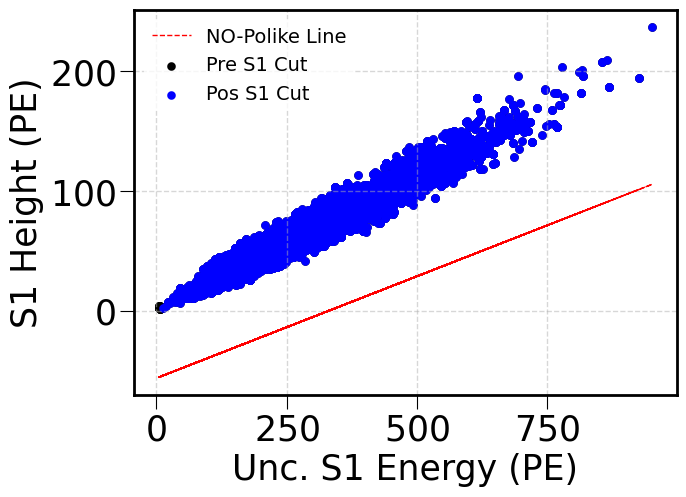

In [53]:
plt.figure(figsize=(7, 5))
plt.scatter(df_doro['S1e'], df_doro['S1h'], alpha=1.0, s=10, c='black', label='Pre S1 Cut')
plt.scatter(S1_doro_df['S1e'], S1_doro_df['S1h'], alpha=1.0, s=10, c='blue', label='Pos S1 Cut')
plt.plot(df_doro['S1e'], M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE, c='red', ls='--', lw=1.0, label='NO-Polike Line')
plt.xlabel('Unc. S1 Energy (PE)')
plt.ylabel('S1 Height (PE)')
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

As you can see, the NO-Polike cut is completely unnecesary.
<br>
I will remain it for homogeneization purposes in the data/MC processing.

#### $S1e$ correction

In [54]:
S1_corr_doro_df = crudo.ef.correct_S1e(S1_doro_df, CV_FIT, DT_CATH, output_column='S1e_corr')     # Based on alpha analysis

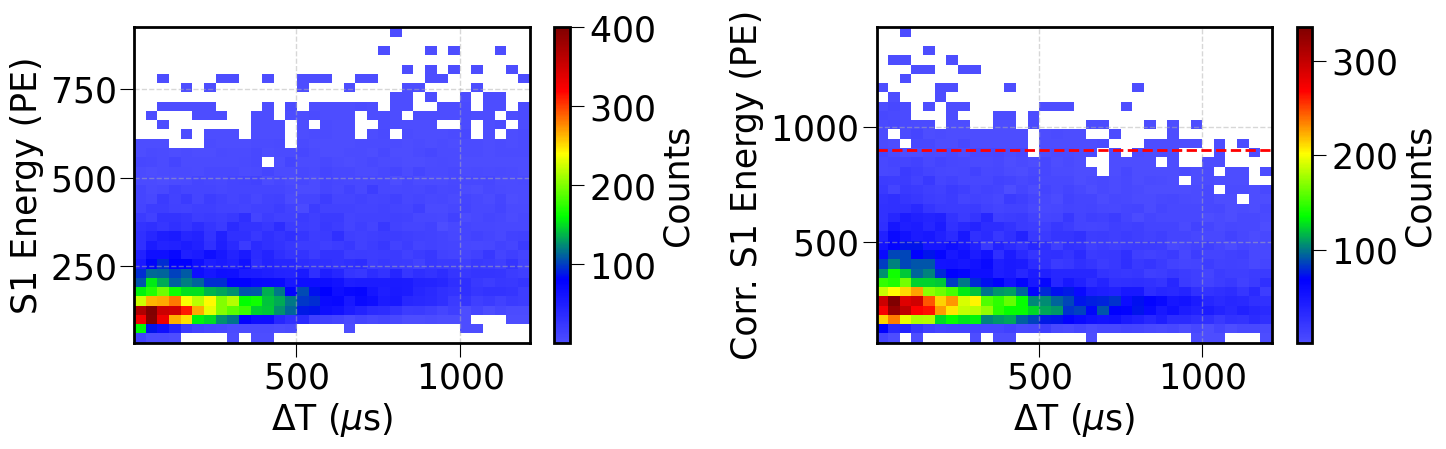

In [55]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(['S1e', 'S1e_corr']):

    # Variables
    E1 = S1_corr_doro_df[col]
    DT = S1_corr_doro_df['DT']
    R = np.sqrt(S1_corr_doro_df['X']**2 + S1_corr_doro_df['Y']**2)

    # Masking
    rad_mask  = (R  < R_UP)
    time_mask = (DT < 0.9*DT_CATH)
    E1 = E1[rad_mask & time_mask]
    DT = DT[rad_mask & time_mask]

    # 2D histogram
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT, E1, x_bins=n_bins, y_bins=n_bins)
    S1e_DT_map = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)

    im = axes[i].pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Counts', shrink=1.0)
    axes[i].set_xlabel('$\Delta$T ($\mu$s)')
    axes[i].set_ylabel('Corr. S1 Energy (PE)' if col == 'S1e_corr' else 'S1 Energy (PE)')
    axes[i].grid(True)

    # Possible alpha/electron limit line
    if col == 'S1e_corr':
        axes[i].axhline(y=S1_ENERGY_THRESHOLD, color='red', ls='--')

plt.tight_layout()
plt.show()

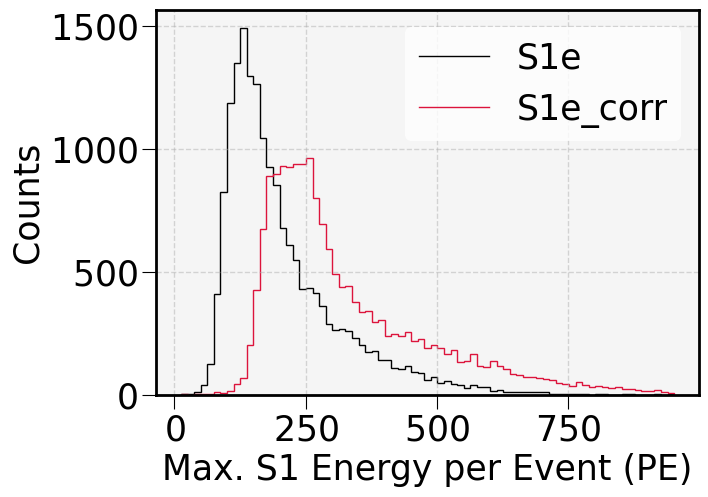

In [56]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

# Histogram
data_one_s1  = S1_corr_doro_df[S1_corr_doro_df['nS1'] == 1].copy()
_, s1e_edges = np.histogram(data_one_s1['S1e'], bins=n_bins)

for i, col in enumerate(['S1e', 'S1e_corr']):

    S1e_event = data_one_s1.groupby('event')[col].max()         # Max. S1e per event
    s1e_counts, _ = np.histogram(S1e_event, bins=s1e_edges)

    # Plotting
    plt.stairs(s1e_counts, s1e_edges, label=col,
               fill=False, lw=1.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Styling
plt.xlabel(f'Max. S1 Energy per Event (PE)')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

#### Execution

In [57]:
df_doro = S1_corr_doro_df.copy()
df_soph = S1_soph_df.copy()

print(f"After S1 cut & correction: {df_soph['event'].nunique()} events.")

After S1 cut & correction: 17968 events.


### NO Spurious Hits

#### Clustering

We first cluster hits in each event using DBSCAN algorithm, tagging -1 hits as noisy hits.

In [58]:
df_clustered = CLUSTER_FUNCTION(df_soph)
df_clustered

,event,time,npeak,Xpeak,X,Y,Z,Q,Ec,cluster
0,0,1.409694e+06,0,165.501045,165.475,75.875,935.615617,5.159420,0.010829,0
1,0,1.409694e+06,0,165.501045,149.925,75.875,939.026779,9.333333,0.002291,0
2,0,1.409694e+06,0,165.501045,149.925,106.975,939.026779,5.101449,0.001261,0
3,0,1.409694e+06,0,165.501045,165.475,60.325,939.026779,9.217392,0.002260,0
4,0,1.409694e+06,0,165.501045,165.475,75.875,939.026779,16.000000,0.003936,0
...,...,...,...,...,...,...,...,...,...,...
3985692,439156,8.783134e+11,2,411.531016,427.825,-248.175,285.523043,7.826087,0.001509,2
3985693,439156,8.783134e+11,2,411.531016,396.725,-248.175,288.472969,5.101449,0.001671,2
3985694,439156,8.783134e+11,2,411.531016,412.275,-263.725,288.472969,17.565218,0.007511,2
3985695,439156,8.783134e+11,2,411.531016,412.275,-248.175,288.472969,5.971014,0.002334,2


Event 326708:


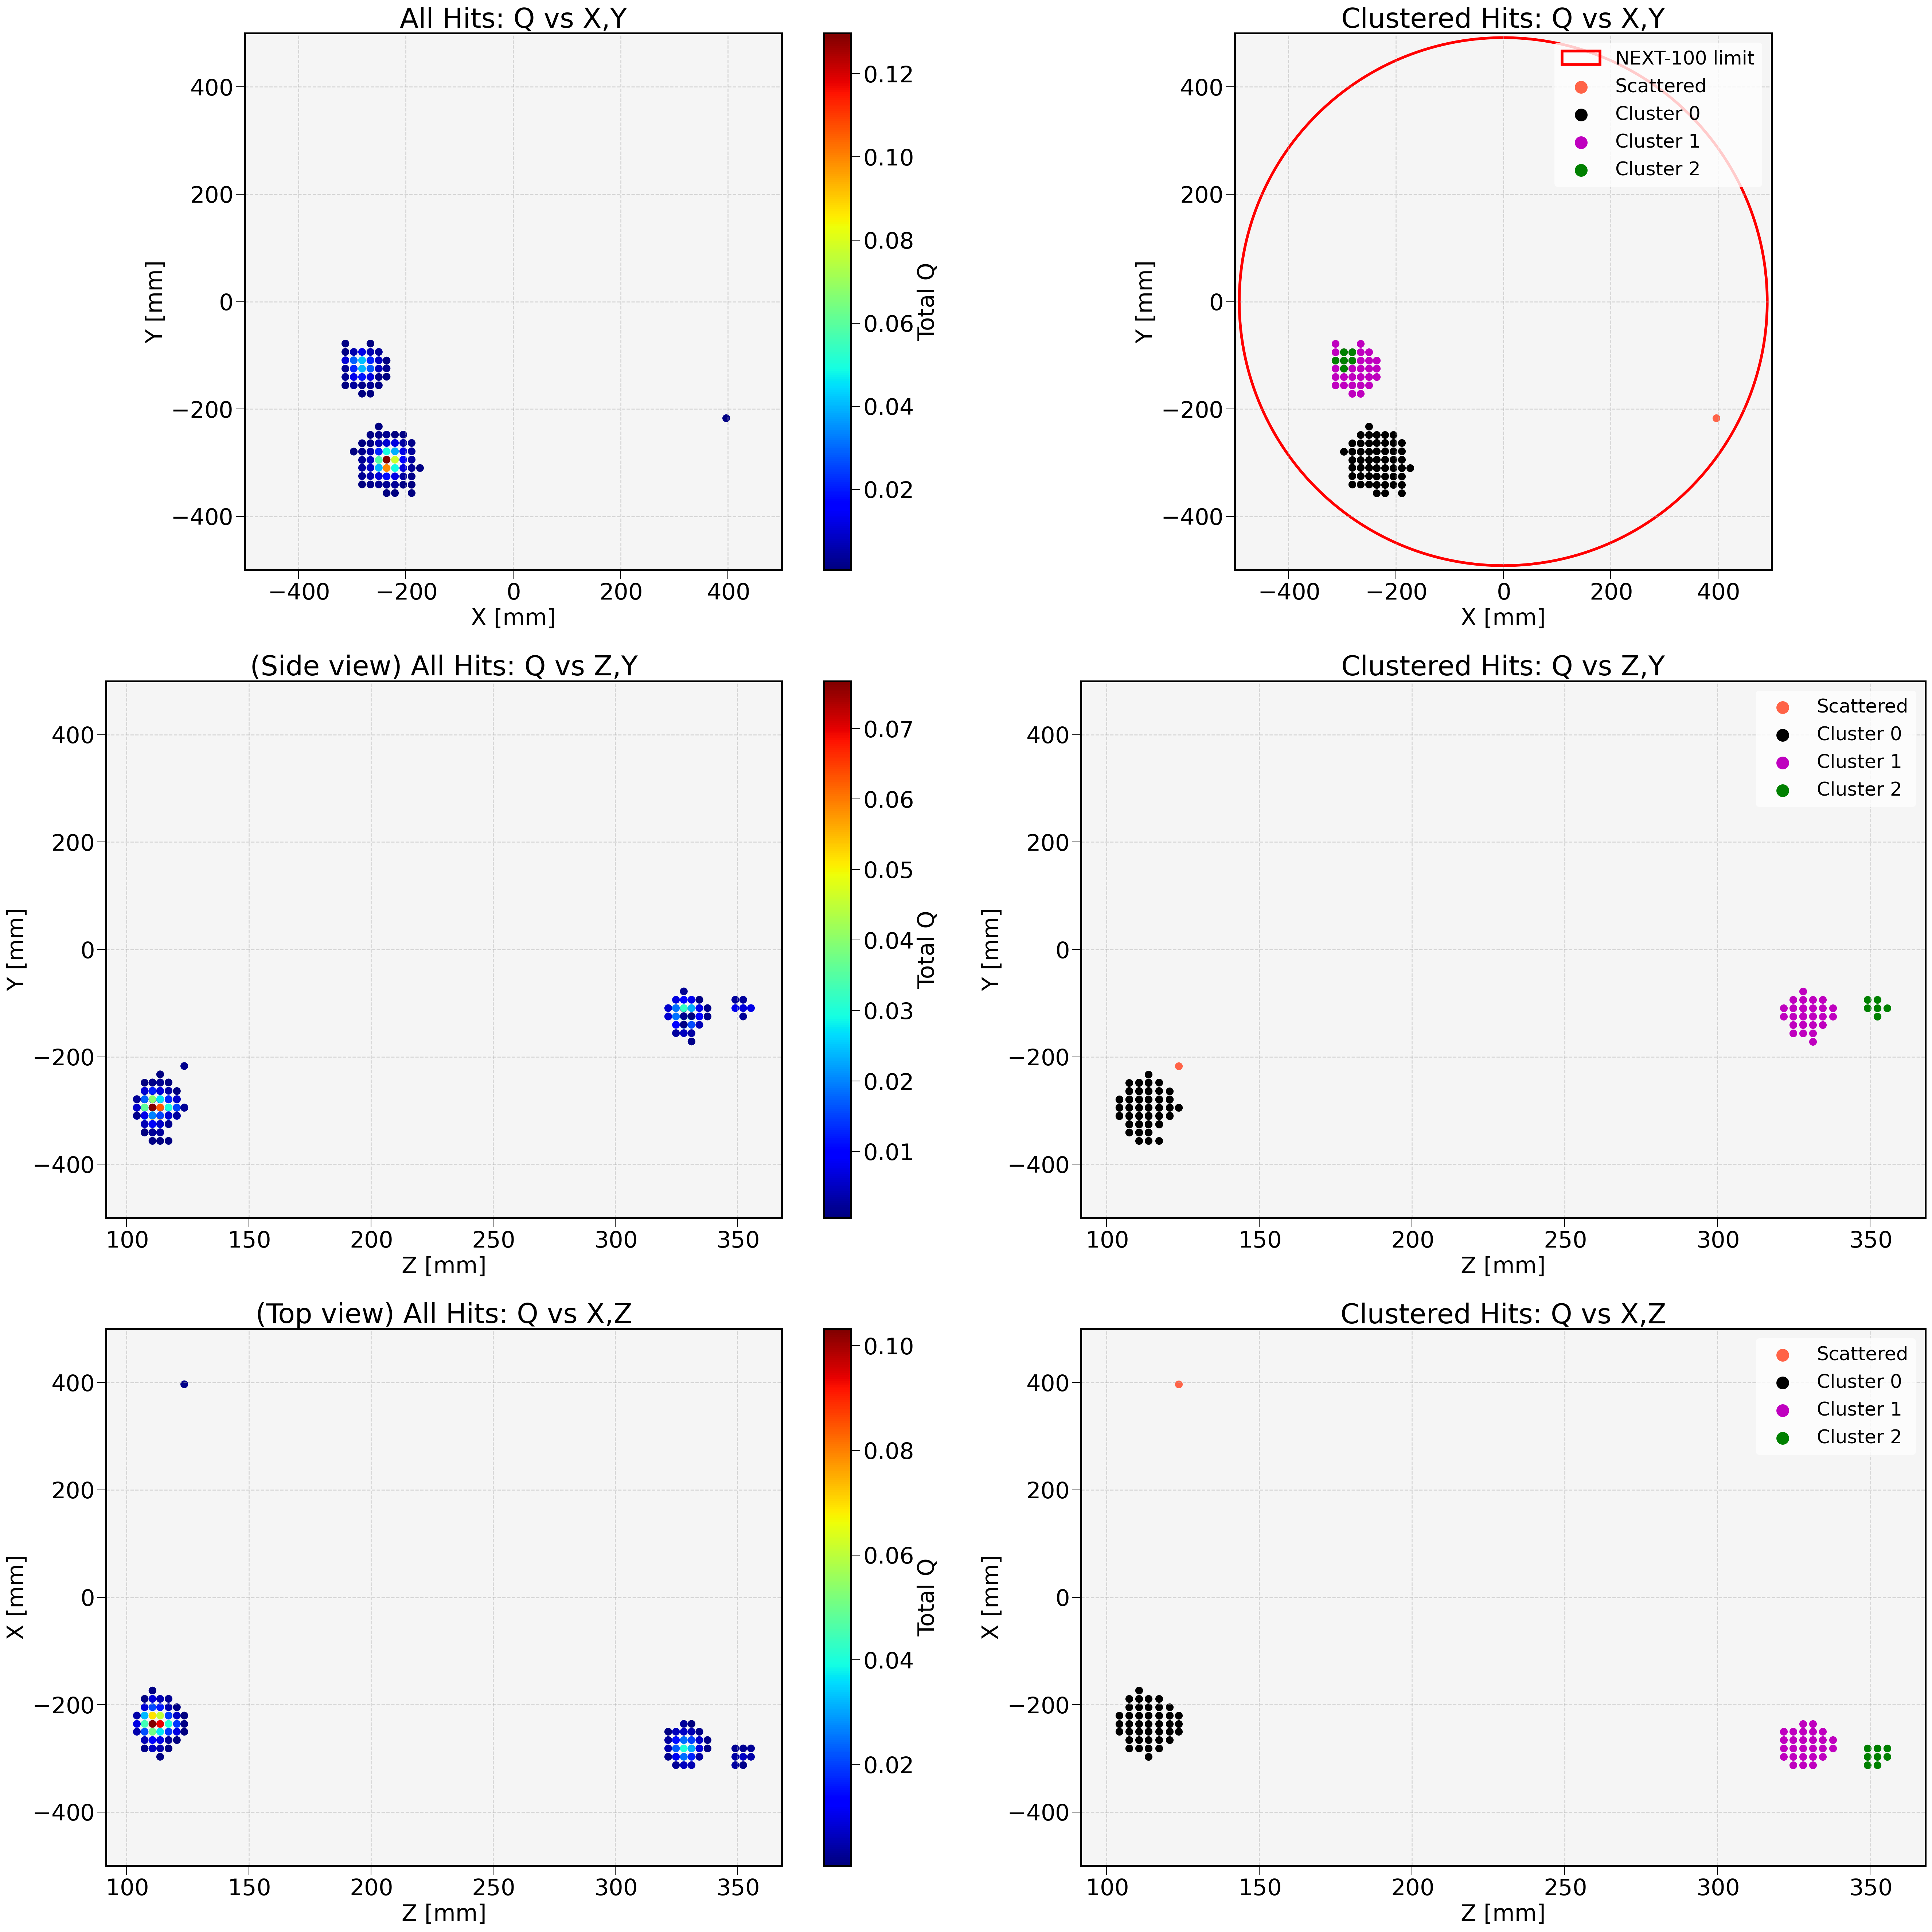

In [59]:
# Pick a random event from the clustered dataframe to visualize its hits
clust_evt_ids = df_clustered['event'].unique()

# Event information + visualization
evt_test_id = np.random.choice(clust_evt_ids)
print(f"Event {evt_test_id}:")
crudo.pt.display_event_cluster(df_clustered, variable='Ec', event=evt_test_id)

#### Energy re-distribution

In [61]:
clean_soph_df = crudo.tf.deal_spurious_hits(df_clustered, energy_column='Ec', output_column='E_hit_mev')
print(f"After cleaning spurious hits: {clean_soph_df['event'].nunique()} events.")

After cleaning spurious hits: 17966 events.


Check some event displays!

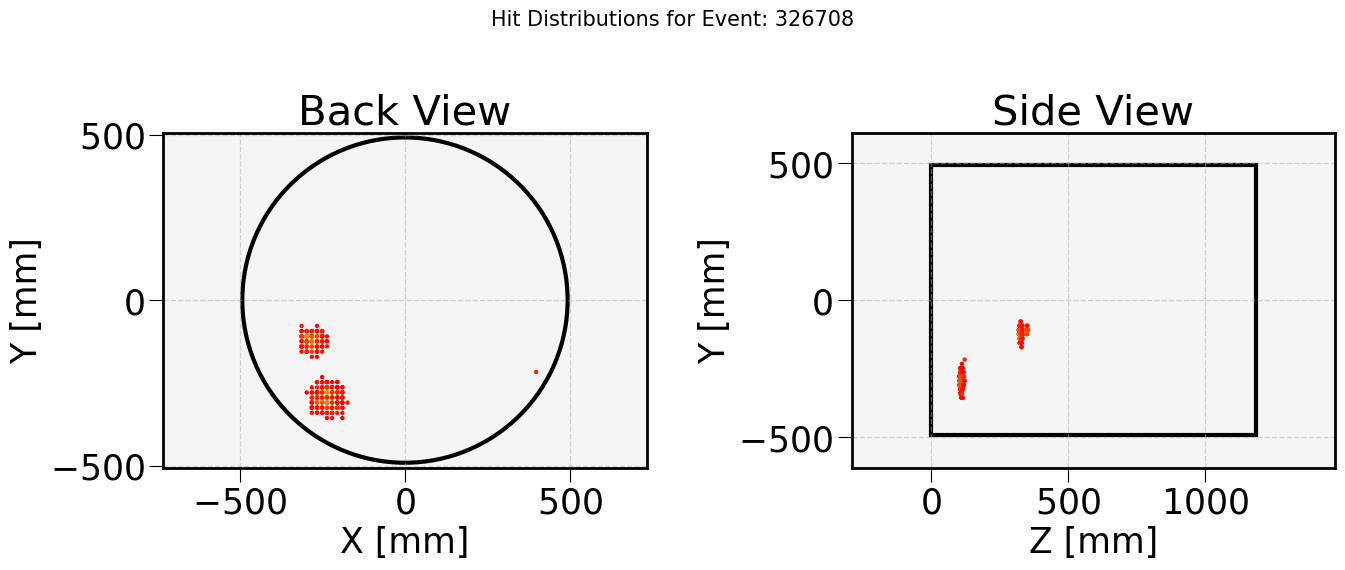

In [62]:
crudo.pt.event_display(df_soph, variable='Ec', event=evt_test_id)

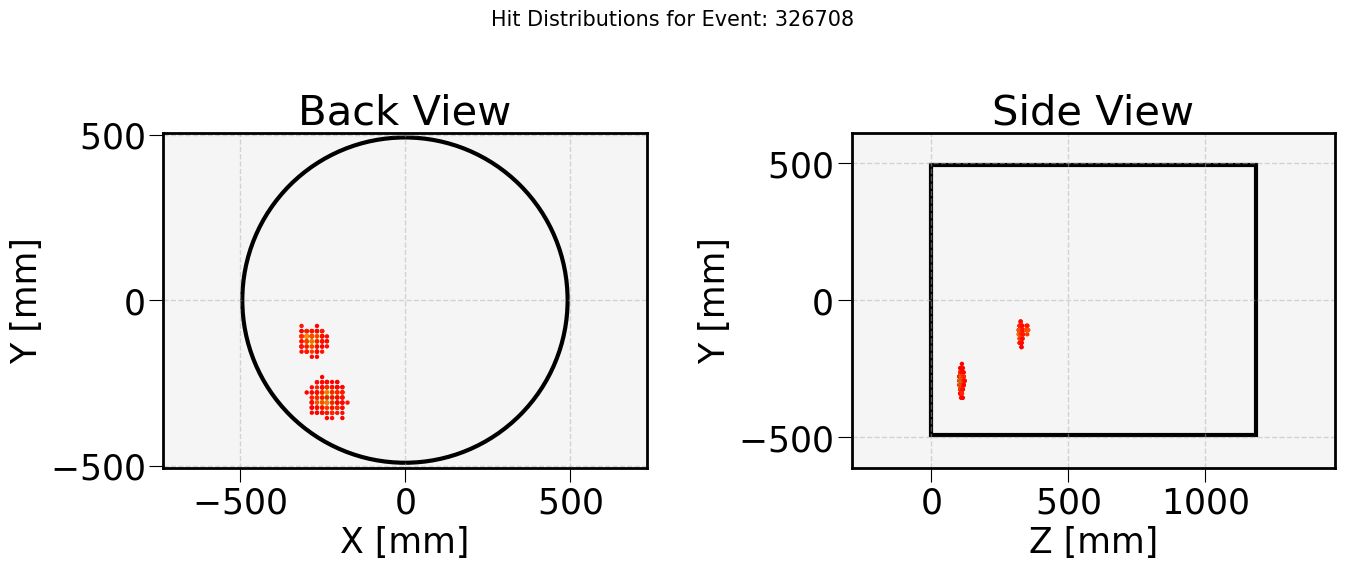

In [63]:
crudo.pt.event_display(clean_soph_df, variable='E_hit_mev', event=evt_test_id)

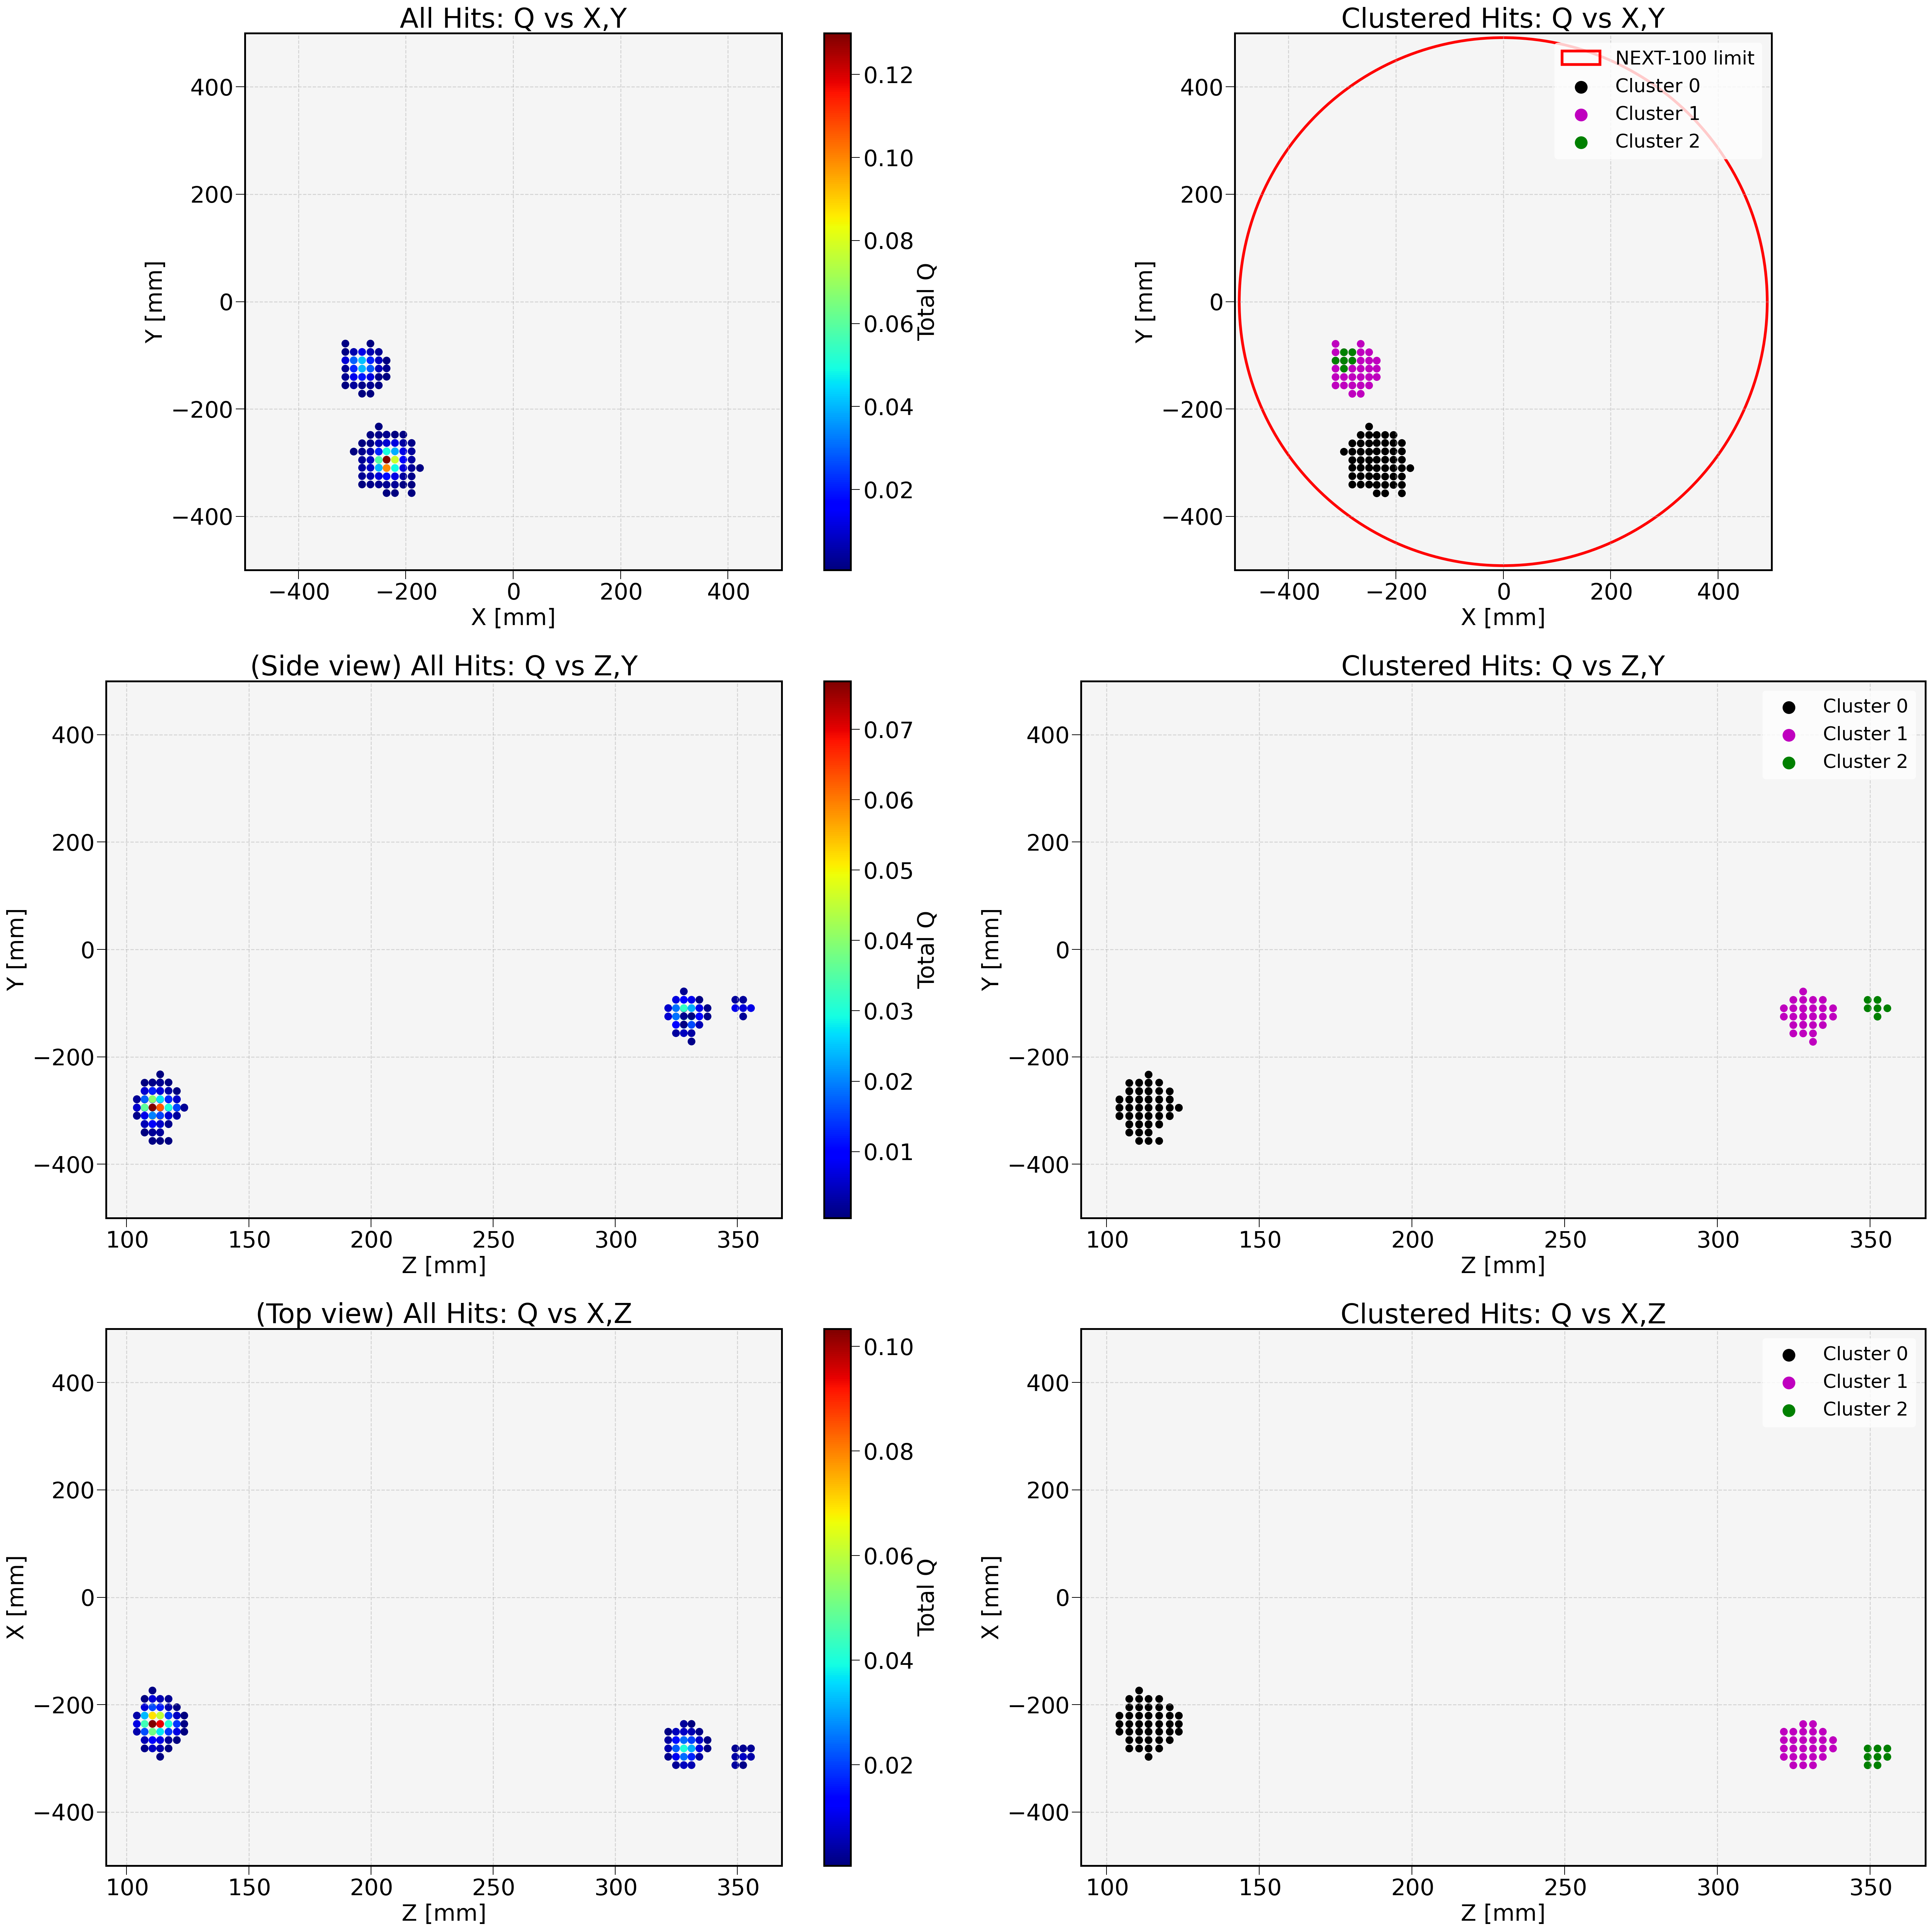

In [64]:
crudo.pt.display_event_cluster(clean_soph_df, variable='E_hit_mev', event=evt_test_id)

#### Update

We do not save the clean dataframe yet, cause' I need old Sophronia dataframe for storage purposes.

In [65]:
after_hits_treatment_ids = clean_soph_df['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_hits_treatment_ids)
print(f"After dealing with spurious hits: {df_soph['event'].nunique()} events.")

After dealing with spurious hits: 17966 events.


In [66]:
clean_soph_df

,event,time,npeak,Xpeak,X,Y,Z,Q,Ec,cluster,E_hit_mev
0,0,1.409694e+06,0,165.501045,165.475,75.875,935.615617,5.159420,0.010829,0,0.010829
1,0,1.409694e+06,0,165.501045,149.925,75.875,939.026779,9.333333,0.002291,0,0.002291
2,0,1.409694e+06,0,165.501045,149.925,106.975,939.026779,5.101449,0.001261,0,0.001261
3,0,1.409694e+06,0,165.501045,165.475,60.325,939.026779,9.217392,0.002260,0,0.002260
4,0,1.409694e+06,0,165.501045,165.475,75.875,939.026779,16.000000,0.003936,0,0.003936
...,...,...,...,...,...,...,...,...,...,...,...
3963088,439156,8.783134e+11,2,411.531016,427.825,-248.175,285.523043,7.826087,0.001509,2,0.001514
3963089,439156,8.783134e+11,2,411.531016,396.725,-248.175,288.472969,5.101449,0.001671,2,0.001677
3963090,439156,8.783134e+11,2,411.531016,412.275,-263.725,288.472969,17.565218,0.007511,2,0.007537
3963091,439156,8.783134e+11,2,411.531016,412.275,-248.175,288.472969,5.971014,0.002334,2,0.002342


### Data @ Event/Peak-level

#### From Dorothea & old Sophronia

In [67]:
original_evt_size_df = df_soph.groupby('event').size().rename('old_event_size').reset_index()
df_doro = df_doro.merge(original_evt_size_df, on='event', how='left')

In [69]:
# df_doro.event.nunique()
df_doro

,event,time,nS1,nS2,S1w,S1h,S1e,S1t,S2w,S2h,...,S2t,DT,X,Y,Z,isotope,volume,pair_prod,S1e_corr,old_event_size
0,0,1.409694e+06,1,3,500.0,80.004669,354.932190,10000.0,55.150,8188.932129,...,1.101481e+06,1091.480957,165.501045,80.959159,949.588379,Bi214,ANODE_RING,False,391.798539,389
1,0,1.409694e+06,1,3,500.0,80.004669,354.932190,10000.0,49.750,3313.922363,...,1.184493e+06,1174.493164,48.526615,247.311046,1021.809021,Bi214,ANODE_RING,False,379.152681,389
2,0,1.409694e+06,1,3,500.0,80.004669,354.932190,10000.0,65.750,2145.103027,...,1.260492e+06,1250.492188,199.079762,176.370369,1087.928101,Bi214,ANODE_RING,False,368.270439,389
3,1,2.395909e+06,1,1,475.0,20.888065,92.482758,10000.0,13.500,13704.273438,...,3.248660e+04,22.486599,-317.925545,360.901890,19.563339,Bi214,ANODE_RING,False,178.947606,93
4,2,5.143776e+06,1,3,525.0,45.245510,225.491531,10025.0,10.475,8612.539062,...,4.050021e+04,30.475216,-47.462861,-471.957334,26.513437,Bi214,ANODE_RING,False,433.869178,253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29666,439154,8.783095e+11,1,1,500.0,34.576591,166.856125,10025.0,47.400,6233.221191,...,4.064922e+05,396.467255,-385.406375,-231.311699,344.926514,Bi214,ANODE_RING,False,255.547700,185
29667,439155,8.783116e+11,1,1,600.0,53.620178,236.292191,10000.0,40.625,15176.583984,...,5.294861e+05,519.486145,257.844650,-24.398017,451.952911,Bi214,ANODE_RING,False,338.667485,207
29668,439156,8.783134e+11,1,3,500.0,23.122528,112.482140,10050.0,19.250,11792.593750,...,1.334959e+05,123.445930,338.546679,-111.117690,107.397949,Bi214,ANODE_RING,False,203.197125,139
29669,439156,8.783134e+11,1,3,500.0,23.122528,112.482140,10050.0,26.175,4773.626465,...,3.024838e+05,292.433807,319.993039,-197.958702,254.417389,Bi214,ANODE_RING,False,182.877125,139


In [71]:
doro_info_df = crudo.dm.get_primary_pulse_info(df_doro, event_level_cols=EVENT_LEVEL_COLS)
doro_info_df

,event,nS1,nS2,isotope,volume,pair_prod,old_event_size,time,main_S1e,main_S1e_corr,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q
0,0,1,3,Bi214,ANODE_RING,False,389,1.409694e+06,354.932190,391.798539,500.0,80.004669,10000.0,133798.078125,55.150,8188.932129,1.101481e+06,4662.145508
1,1,1,1,Bi214,ANODE_RING,False,93,2.395909e+06,92.482758,178.947606,475.0,20.888065,10000.0,61392.496094,13.500,13704.273438,3.248660e+04,3668.521729
2,2,1,3,Bi214,ANODE_RING,False,253,5.143776e+06,225.491531,433.869178,525.0,45.245510,10025.0,67209.609375,58.100,3897.791748,1.197483e+06,2151.304199
3,3,1,2,Bi214,ANODE_RING,False,148,7.902906e+06,91.370972,159.903930,375.0,28.887613,10000.0,64399.585938,25.825,8718.295898,1.824874e+05,2514.376709
4,5,1,2,Bi214,ANODE_RING,False,128,1.011482e+07,91.436638,154.983211,375.0,23.536798,10000.0,52948.929688,24.525,6900.153320,2.334961e+05,1928.811523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,439152,1,3,Bi214,ANODE_RING,False,170,8.783049e+11,153.914566,281.178736,500.0,38.854275,10000.0,98131.085938,34.350,8979.500977,4.294928e+05,3451.825928
17962,439153,1,1,Bi214,ANODE_RING,False,99,8.783069e+11,98.653450,184.519882,375.0,22.089136,10000.0,105716.054688,25.450,18923.558594,8.148605e+04,3736.115967
17963,439154,1,1,Bi214,ANODE_RING,False,185,8.783095e+11,166.856125,255.547700,500.0,34.576591,10025.0,112573.664062,47.400,6233.221191,4.064922e+05,5068.173828
17964,439155,1,1,Bi214,ANODE_RING,False,207,8.783116e+11,236.292191,338.667485,600.0,53.620178,10000.0,197355.156250,40.625,15176.583984,5.294861e+05,7682.145508


#### From Sophronia (NO spurious hits)

In [72]:
clean_soph_df

,event,time,npeak,Xpeak,X,Y,Z,Q,Ec,cluster,E_hit_mev
0,0,1.409694e+06,0,165.501045,165.475,75.875,935.615617,5.159420,0.010829,0,0.010829
1,0,1.409694e+06,0,165.501045,149.925,75.875,939.026779,9.333333,0.002291,0,0.002291
2,0,1.409694e+06,0,165.501045,149.925,106.975,939.026779,5.101449,0.001261,0,0.001261
3,0,1.409694e+06,0,165.501045,165.475,60.325,939.026779,9.217392,0.002260,0,0.002260
4,0,1.409694e+06,0,165.501045,165.475,75.875,939.026779,16.000000,0.003936,0,0.003936
...,...,...,...,...,...,...,...,...,...,...,...
3963088,439156,8.783134e+11,2,411.531016,427.825,-248.175,285.523043,7.826087,0.001509,2,0.001514
3963089,439156,8.783134e+11,2,411.531016,396.725,-248.175,288.472969,5.101449,0.001671,2,0.001677
3963090,439156,8.783134e+11,2,411.531016,412.275,-263.725,288.472969,17.565218,0.007511,2,0.007537
3963091,439156,8.783134e+11,2,411.531016,412.275,-248.175,288.472969,5.971014,0.002334,2,0.002342


In [73]:
df_final_soph = clean_soph_df.loc[:, FINAL_SOPH_COLUMNS].copy()
df_final_soph

,event,time,npeak,X,Y,Z,E_hit_mev,cluster
0,0,1.409694e+06,0,165.475,75.875,935.615617,0.010829,0
1,0,1.409694e+06,0,149.925,75.875,939.026779,0.002291,0
2,0,1.409694e+06,0,149.925,106.975,939.026779,0.001261,0
3,0,1.409694e+06,0,165.475,60.325,939.026779,0.002260,0
4,0,1.409694e+06,0,165.475,75.875,939.026779,0.003936,0
...,...,...,...,...,...,...,...,...
3963088,439156,8.783134e+11,2,427.825,-248.175,285.523043,0.001514,2
3963089,439156,8.783134e+11,2,396.725,-248.175,288.472969,0.001677,2
3963090,439156,8.783134e+11,2,412.275,-263.725,288.472969,0.007537,2
3963091,439156,8.783134e+11,2,412.275,-248.175,288.472969,0.002342,2


In [81]:
soph_event_info_df = crudo.dm.summarize_hits_to_event_level(df_final_soph)
soph_event_info_df

,event,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,E_evt_mev,n_cluster,event_size
0,0,146.908041,146.180236,992.816666,10.975,257.775,29.225,291.575,935.615617,1109.070997,324.512220,0.936131,3,388
1,1,-316.463657,359.213122,18.360941,-359.225,-235.825,307.625,415.475,14.098165,22.113419,539.195680,0.299357,1,93
2,2,-7.879277,-150.606552,700.584603,-373.775,288.875,-479.925,152.625,24.574856,1042.861279,489.604709,0.659713,3,252
3,3,-96.689480,52.389381,291.860453,-435.975,412.275,-124.775,307.625,143.458732,541.611594,505.250909,0.432282,2,147
4,5,-369.034063,-73.939816,214.977514,-435.975,-312.575,-155.875,29.725,189.526985,244.650362,437.182829,0.421491,2,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,439152,-144.814402,199.321034,277.861475,-265.925,-50.225,-62.575,353.775,90.329021,371.040754,363.002075,0.607300,3,169
17962,439153,-190.318396,-216.807627,62.578111,-265.925,-142.525,-294.325,-139.825,57.718852,73.247584,367.625191,0.422903,1,99
17963,439154,-390.547195,-234.121226,350.143826,-435.975,-328.125,-279.275,-185.975,336.484191,366.551282,509.534176,0.583532,1,185
17964,439155,261.167957,-26.630003,452.080975,181.025,319.975,-94.175,29.725,443.291861,463.123076,326.036242,0.795805,1,207


In [82]:
soph_peak_info_df = df_final_soph.groupby(['event', 'npeak']).agg(E_peak_mev=('E_hit_mev', 'sum')).reset_index()
soph_peak_info_df

,event,npeak,E_peak_mev
0,0,0,0.535347
1,0,1,0.227933
2,0,2,0.172850
3,1,0,0.299357
4,2,0,0.198624
...,...,...,...
29209,439154,0,0.583532
29210,439155,0,0.795805
29211,439156,0,0.281273
29212,439156,1,0.170698


#### Aggregate

In [ ]:
df_file = pd.merge(soph_peak_info_df, soph_event_info_df, on='event', how='left')
df_file = pd.merge(df_file, doro_info_df, on='event', how='left')
df_file

,event,npeak,E_peak_mev,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,...,main_S1e,main_S1e_corr,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q
0,0,0,0.535347,146.908041,146.180236,992.816666,10.975,257.775,29.225,291.575,...,354.932190,391.798539,500.0,80.004669,10000.0,133798.078125,55.150,8188.932129,1.101481e+06,4662.145508
1,0,1,0.227933,146.908041,146.180236,992.816666,10.975,257.775,29.225,291.575,...,354.932190,391.798539,500.0,80.004669,10000.0,133798.078125,55.150,8188.932129,1.101481e+06,4662.145508
2,0,2,0.172850,146.908041,146.180236,992.816666,10.975,257.775,29.225,291.575,...,354.932190,391.798539,500.0,80.004669,10000.0,133798.078125,55.150,8188.932129,1.101481e+06,4662.145508
3,1,0,0.299357,-316.463657,359.213122,18.360941,-359.225,-235.825,307.625,415.475,...,92.482758,178.947606,475.0,20.888065,10000.0,61392.496094,13.500,13704.273438,3.248660e+04,3668.521729
4,2,0,0.198624,-7.879277,-150.606552,700.584603,-373.775,288.875,-479.925,152.625,...,225.491531,433.869178,525.0,45.245510,10025.0,67209.609375,58.100,3897.791748,1.197483e+06,2151.304199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29209,439154,0,0.583532,-390.547195,-234.121226,350.143826,-435.975,-328.125,-279.275,-185.975,...,166.856125,255.547700,500.0,34.576591,10025.0,112573.664062,47.400,6233.221191,4.064922e+05,5068.173828
29210,439155,0,0.795805,261.167957,-26.630003,452.080975,181.025,319.975,-94.175,29.725,...,236.292191,338.667485,600.0,53.620178,10000.0,197355.156250,40.625,15176.583984,5.294861e+05,7682.145508
29211,439156,0,0.281273,341.478407,-151.798811,170.698670,288.875,427.825,-279.275,-62.575,...,112.482140,203.197125,500.0,23.122528,10050.0,68739.898438,19.250,11792.593750,1.334959e+05,2420.289795
29212,439156,1,0.170698,341.478407,-151.798811,170.698670,288.875,427.825,-279.275,-62.575,...,112.482140,203.197125,500.0,23.122528,10050.0,68739.898438,19.250,11792.593750,1.334959e+05,2420.289795


: 

In [6]:
test_path = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/processed_mc_hpr_background_Bi214_30042026.h5'

In [7]:
crudo.dm.h5_describer(test_path)

Events (Group)
  Events/_i_table (Group)
    Events/_i_table/E_evt_mev (Group)
      Events/_i_table/E_evt_mev/abounds (Dataset)
        Shape: (1728,), Dtype: float64
      Events/_i_table/E_evt_mev/bounds (Dataset)
        Shape: (9, 191), Dtype: float64
      Events/_i_table/E_evt_mev/indices (Dataset)
        Shape: (9, 393216), Dtype: uint32
      Events/_i_table/E_evt_mev/indicesLR (Dataset)
        Shape: (393216,), Dtype: uint32
      Events/_i_table/E_evt_mev/mbounds (Dataset)
        Shape: (1728,), Dtype: float64
      Events/_i_table/E_evt_mev/mranges (Dataset)
        Shape: (9,), Dtype: float64
      Events/_i_table/E_evt_mev/ranges (Dataset)
        Shape: (9, 2), Dtype: float64
      Events/_i_table/E_evt_mev/sorted (Dataset)
        Shape: (9, 393216), Dtype: float64
      Events/_i_table/E_evt_mev/sortedLR (Dataset)
        Shape: (393409,), Dtype: float64
      Events/_i_table/E_evt_mev/zbounds (Dataset)
        Shape: (1728,), Dtype: float64
    Events/_i_table/E_pe

In [8]:
test_df = pd.read_hdf(test_path, key='Events')

In [9]:
test_df

,event,npeak,E_peak_mev,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,...,time,main_S1e,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q
0,0,0,0.535347,146.908041,146.180236,992.816666,10.975,257.775,29.225,291.575,...,1.409694e+06,354.932190,500.0,80.004669,10000.0,133798.078125,55.150,8188.932129,1.101481e+06,4662.145508
1,0,1,0.227933,146.908041,146.180236,992.816666,10.975,257.775,29.225,291.575,...,1.409694e+06,354.932190,500.0,80.004669,10000.0,133798.078125,55.150,8188.932129,1.101481e+06,4662.145508
2,0,2,0.172850,146.908041,146.180236,992.816666,10.975,257.775,29.225,291.575,...,1.409694e+06,354.932190,500.0,80.004669,10000.0,133798.078125,55.150,8188.932129,1.101481e+06,4662.145508
3,1,0,0.299357,-316.463657,359.213122,18.360941,-359.225,-235.825,307.625,415.475,...,2.395909e+06,92.482758,475.0,20.888065,10000.0,61392.496094,13.500,13704.273438,3.248660e+04,3668.521729
4,2,0,0.198624,-7.879277,-150.606552,700.584603,-373.775,288.875,-479.925,152.625,...,5.143776e+06,225.491531,525.0,45.245510,10025.0,67209.609375,58.100,3897.791748,1.197483e+06,2151.304199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3852885,1079049185,0,0.833531,206.106599,169.216921,529.313760,149.925,273.325,106.975,260.475,...,2.158098e+15,262.742859,450.0,52.199734,10000.0,206885.031250,47.600,12360.762695,6.184868e+05,7669.100586
3852886,1079049186,0,0.908556,-250.372480,222.976255,1073.317935,-312.575,-173.625,137.575,291.575,...,2.158098e+15,386.983490,575.0,101.135338,10000.0,211744.171875,69.800,10088.241211,1.242484e+06,8379.014648
3852887,1079049187,0,1.774447,-103.167663,153.178383,873.962775,-189.175,-34.675,75.875,230.375,...,2.158098e+15,632.581604,550.0,142.464554,10000.0,443269.187500,95.725,13561.026367,1.008487e+06,17778.318359
3852888,1079049188,0,1.334043,223.502543,30.086056,1016.879485,104.275,490.025,-63.075,137.575,...,2.158098e+15,578.808228,575.0,119.091682,10000.0,331492.093750,92.025,16926.326172,1.159487e+06,13076.580078


# Selection

Ok, so we start from this dataframes...

In [74]:
df_event

,event,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_mev,n_cluster,time,nS1,nS2,S1e,S1e_corr
0,0,169.343029,4.040181,1048.267768,660.045456,1275.048836,511.922832,1.056133,3,1.434202e+06,1,4,343.0,437.000344
1,1,-311.193402,256.576148,1151.741938,1133.088217,1188.223489,528.117758,0.488223,0,2.309077e+06,1,2,246.0,250.688353
2,4,-389.348785,-251.846303,1220.717102,1156.417702,1294.694959,539.255604,0.936507,1,9.143824e+06,1,2,279.0,280.393556
3,5,-427.131233,139.167993,1177.332623,1164.223125,1195.189253,506.334036,0.356754,0,1.199260e+07,1,2,162.0,163.164429
4,6,-273.631751,-316.367478,1064.283783,1052.100026,1075.893765,473.768858,0.247048,0,1.368604e+07,1,2,128.0,135.265437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770,3826,-279.663650,374.313384,1172.976130,1149.475103,1190.832510,507.585595,0.498026,0,7.652959e+09,1,1,272.0,273.856537
2771,3827,-100.481861,-177.575017,1197.528292,1175.482448,1220.239271,492.398285,0.453498,0,7.655161e+09,1,1,53.0,52.692580
2772,3828,213.687952,-39.303139,1232.278112,1174.700100,1295.807906,275.247491,0.290745,1,7.656743e+09,1,2,32.0,32.102059
2773,3829,1.053989,60.851211,1179.999670,1157.381228,1295.469368,128.958487,0.398055,1,7.658624e+09,1,2,208.0,209.800794


In [76]:
print(f"Events according hits dataframe: {test_soph.event.nunique()}")
test_soph

Events according hits dataframe: 2775


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,cluster
0,0,1.434202e+06,0,84.813773,163.882205,1,-126.975,-247.675,0.0,0.0,660.045456,15.594203,72.000000,-1.0,0.000183,-1,-1.0,-1
1,0,1.434202e+06,0,84.813773,163.882205,1,88.725,152.625,0.0,0.0,666.764139,8.463768,1789.276581,-1.0,0.004442,-1,-1.0,0
2,0,1.434202e+06,0,84.813773,163.882205,1,88.725,168.175,0.0,0.0,666.764139,7.884058,1666.723419,-1.0,0.004131,-1,-1.0,0
3,0,1.434202e+06,0,84.813773,163.882205,1,57.625,168.175,0.0,0.0,670.186176,6.260870,357.981558,-1.0,0.000885,-1,-1.0,0
4,0,1.434202e+06,0,84.813773,163.882205,1,57.625,199.275,0.0,0.0,670.186176,7.014493,401.071921,-1.0,0.000996,-1,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3764461,3830,7.661317e+09,0,-254.521696,114.991174,1,-265.925,122.025,0.0,0.0,1184.891606,6.724638,656.792542,-1.0,0.001700,-1,-1.0,0
3764462,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,106.475,0.0,0.0,1184.891606,5.449275,532.228466,-1.0,0.001370,-1,-1.0,0
3764463,3830,7.661317e+09,0,-254.521696,114.991174,1,-250.375,122.025,0.0,0.0,1184.891606,7.246377,707.750620,-1.0,0.001827,-1,-1.0,0
3764464,3830,7.661317e+09,0,-254.521696,114.991174,1,-235.825,106.975,0.0,0.0,1184.891606,6.086957,594.510504,-1.0,0.001523,-1,-1.0,0


## Trigger2 Efficiency: or energy window

In [ ]:
# ----- Trigger 2 Efficiency Cut ----- #
good_trg2_ids = df_event.loc[df_event['E_evt_mev'] >= TRG2_THRESHOLD, 'event'].unique()
print(f"After trigger 2 efficiency ({TRG2_THRESHOLD} MeV): {len(good_trg2_ids)} events ({len(good_trg2_ids)/len(positive_Ec_ids):.2%})")

# Update dataframes
test_doro, test_soph = bf.apply_cut_and_update(test_doro, test_soph, event_ids=good_trg2_ids)
print(f"\nDorothea events = {test_doro.event.nunique()}\nSophronia events = {test_soph.event.nunique()}")

After trigger 2 efficiency (0.5 MeV): 17751 events (64.00%)

Dorothea events = 17751
Sophronia events = 17751


## $S2$ Signal

#### How does it behave the $S2$ energy?

In [ ]:
# ----- nS2 = 1 ----- #
data_S2 = test_doro[test_doro['nS2'] == 1].copy()

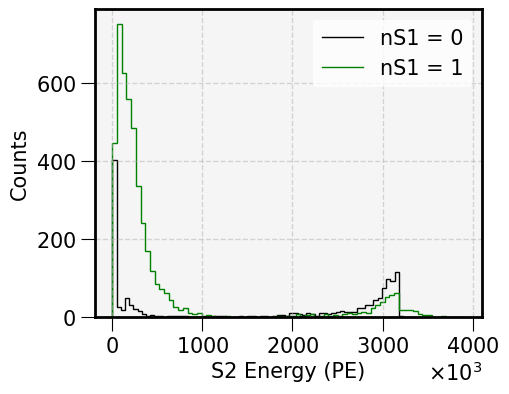

In [ ]:
# Global
n_bins = 75
E2_max = 2000e3

plt.figure(figsize=(5, 4))

for i, label in enumerate(['nS1 = 0', 'nS1 = 1']):
    
    if label == 'nS1 = 0':
        data = data_S2[data_S2['nS1'] == 0].copy()
        E2 = data['S2e']
    else:
        data = data_S2[data_S2['nS1'] == 1].copy()
        E2 = data['S2e']

    # Histogram
    E2_counts, E2_edges = np.histogram(E2, bins=n_bins)

    # Plotting
    plt.stairs(E2_counts, E2_edges, label=label, 
               fill=False, lw=1.0, ec=pt.hist_colors[4*i % len(pt.hist_colors)])

# Styling
plt.xlabel('S2 Energy (PE)')
# plt.xlim(0, E2_max)
plt.ylabel('Counts')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

#### __THESE COMMENTS ARE VALID JUST FOR CATHODE MC FILES__

We know that alpha population is around $1000\times10^{3}\,\text{pe}$.
<br>
The $nS2 = 1$ cut remove almost all the aplha contribution (BiPo coincidence!).
<br>
In any case, let's check that population of events around $3000\times10^{3}\,\text{pe}$.

In [ ]:
pop_3000_ids = data_S2.loc[data_S2['S2e'] >= 1500e3, 'event'].unique()
print(len(pop_3000_ids))

1343


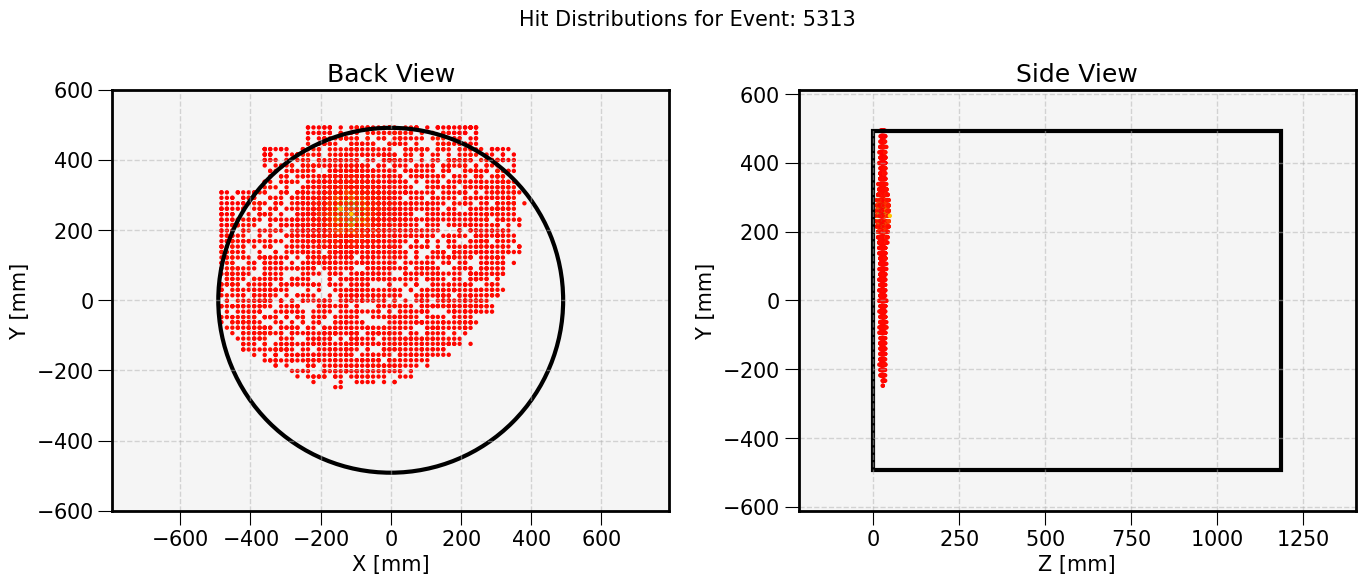

In [ ]:
pt.event_display(test_soph, variable='Ec', event=np.random.choice(pop_3000_ids))

This population seems to be alphas but with so many hits! __Why?__

In [ ]:
pop_std_ids = data_S2.loc[data_S2['S2e'] < 1500e3, 'event'].unique()
print(len(pop_std_ids))

926


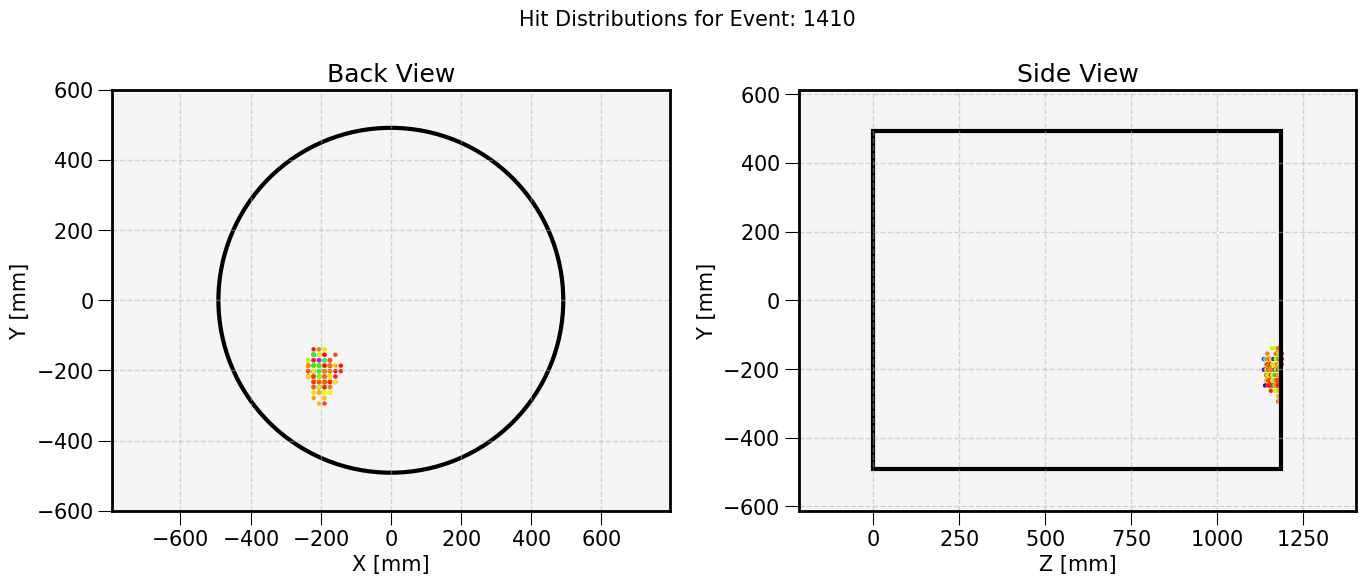

In [ ]:
pt.event_display(test_soph, variable='Ec', event=np.random.choice(pop_std_ids))

Here I notice more events "well-reconstructed", but we still need to distinguish between alphas and electrons.
<br>
First, we apply the $nS2 = 1$ cut.
<br>
__Notice the low efficieny, we are killing the BiPo coincidence!__

### Execution

In [ ]:
# Event counter
evt_prior = test_soph['event'].nunique()

# ----- S2 Signal ----- #
test_doro = test_doro[test_doro['nS2'] == 1].copy()

# Update dataframes
good_evt_03 = test_doro['event'].unique()
test_soph = test_soph[test_soph['event'].isin(good_evt_03)].copy()

print(f"After S2 signal cut: {len(good_evt_03)} events ({len(good_evt_03)/evt_prior:.2%})")

After S2 signal cut: 4684 events (62.54%)


## $\alpha$ and $e$ Populations

__NOTE:__ Just the cathode MC files include $\alpha$ population.

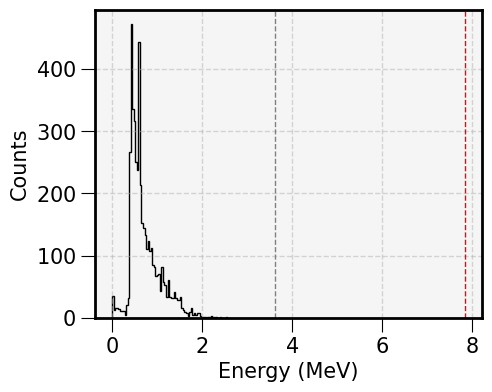

In [ ]:
# Global
n_bins = 75

# Variables
E = test_soph.groupby('event')['Ec'].sum()

# Histogram
E_counts, E_edges = np.histogram(E, bins=n_bins)

# Plotting
plt.figure(figsize=(5, 4))
plt.stairs(E_counts, E_edges,
           fill=False, lw=1.0, ec='black')
    
# 214Po peak as reference!
x_Po = 7.83
plt.axvline(x=x_Po, color='red', ls='--', lw=1)
# plt.text(0.98*x_Po, 300, f'{x_Po} MeV', c='red', ha='right', va='bottom')

# Energy threshold
x_flag = ENERGY_THRESHOLD_MEV
plt.axvline(x=x_flag, color='gray', ls='--', lw=1)
# plt.text(0.98*x_flag, 300, f'{x_flag:.2f} MeV', c='gray', ha='right', va='bottom')

# Styling
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

As alphas, we expect to have them around $7.83\,\text{MeV}$ (the Q value of $^{214}\text{Po}$).
<br>
I will use the same energy threshold to separate alphas and electrons (gray line).

In [ ]:
# Event counter
evt_prior = test_soph['event'].nunique()

# Variables
evt_energy = test_soph.groupby('event')['Ec'].sum()

# Event IDs for alphas and electrons
elec_ids  = evt_energy[evt_energy <= ENERGY_THRESHOLD_MEV].index
alpha_ids = evt_energy[evt_energy >  ENERGY_THRESHOLD_MEV].index

# Update dataframes
test_doro = test_doro[test_doro['event'].isin(elec_ids)].copy()
test_soph = test_soph[test_soph['event'].isin(elec_ids)].copy() 
print(f"Electron candidates: {len(elec_ids)} events ({len(elec_ids)/evt_prior:.2%}) ")

Electron candidates: 4684 events (100.00%) 


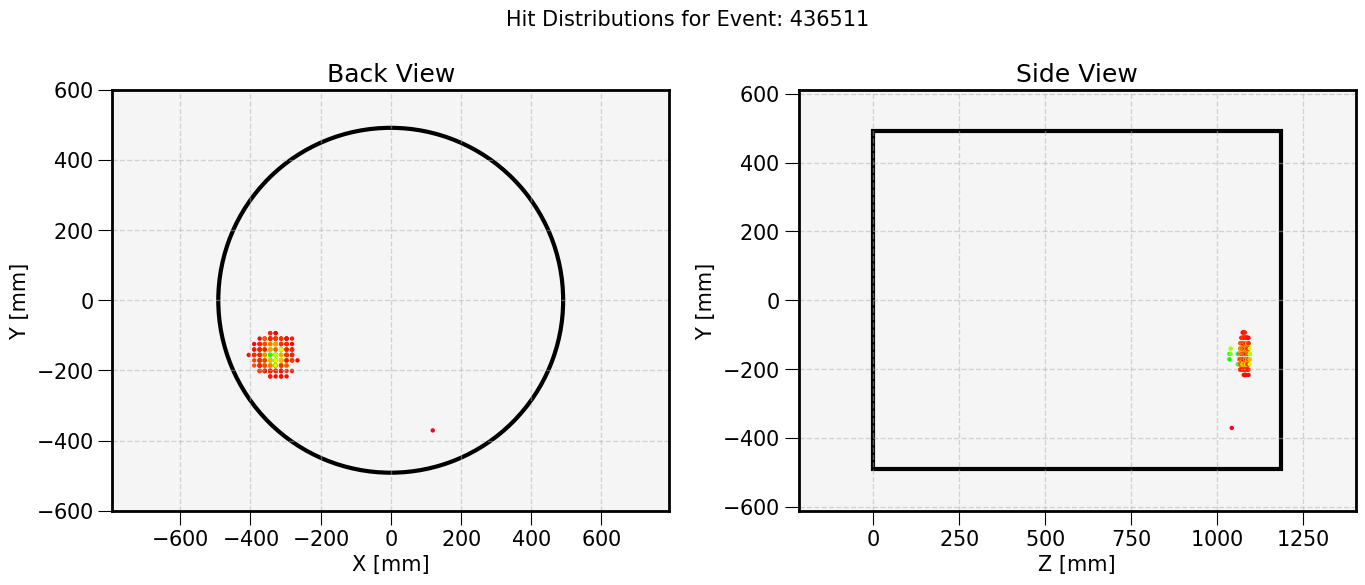

In [ ]:
pt.event_display(test_soph, variable='Ec')

Max. Energy: 2.5634 MeV


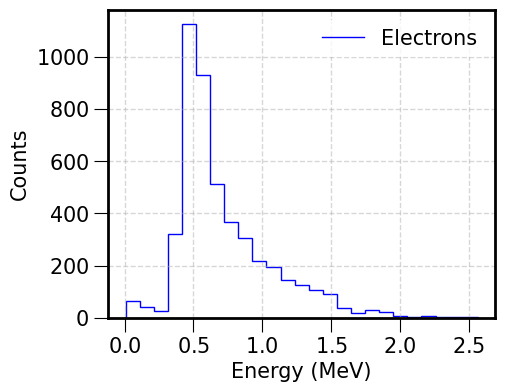

In [ ]:
E_electron_evt = test_soph.groupby('event')['Ec'].sum()
print(f'Max. Energy: {E_electron_evt.max():.4f} MeV')

# Binning
E_electron, e_elec = np.histogram(E_electron_evt, bins=25)

plt.figure(figsize=(5, 4))
plt.stairs(E_electron, e_elec, fill=False, ec='blue', lw=1.0, label='Electrons')
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)
plt.show()